# Deep Learning Benchmark for Hierarchical Zillow Home Sales Forecasting

This notebook evaluates a set of deep learning forecasting models from Nixtla's `NeuralForecast` library for monthly hierarchical Zillow home sales data.

The objective is to compare neural forecasting models under the same rolling-origin cross-validation protocol used in the machine learning benchmark. The evaluated models are:

- Kolmogorov-Arnold Network (KAN)
- NHITS
- NBEATSx
- GRU

In [1]:
# Libraries
import os
import time
import random
import warnings
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from neuralforecast import NeuralForecast
from neuralforecast.models import KAN, NHITS, NBEATSx, GRU
from neuralforecast.losses.pytorch import MAE


warnings.filterwarnings("ignore")
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)

plt.rcParams.update({
    "font.family": "serif",
    "figure.dpi": 300
})

## Load data

The input data must contain at least three columns:

- `unique_id`: time series identifier
- `ds`: timestamp
- `y`: target variable

Additional metadata such as `RegionName`, `StateName`, and `hierarchy_level` is preserved only for interpretation and plotting.

In [2]:
df = pd.read_csv("Data/zillow_houses_hierarchy_cleaned.csv", parse_dates=["ds"])

data = (
    df[["unique_id", "ds", "y"]]
    .copy()
    .sort_values(["unique_id", "ds"])
    .reset_index(drop=True)
)

display(data.head())
print("Rows:", f"{len(data):,}")
print("Series:", data["unique_id"].nunique())
print("Date range:", data["ds"].min(), "to", data["ds"].max())

,unique_id,ds,y
0,US,2008-02-29,174474.0
1,US,2008-03-31,203564.0
2,US,2008-04-30,225601.0
3,US,2008-05-31,248297.0
4,US,2008-06-30,260848.0


Rows: 76,300
Series: 350
Date range: 2008-02-29 00:00:00 to 2026-03-31 00:00:00


In [3]:
horizon = 12
n_windows = 5
step_size = 12
freq = "ME"

random_seed = 42

np.random.seed(random_seed)
random.seed(random_seed)

try:
    import torch
    torch.manual_seed(random_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(random_seed)
        print("GPU available:", torch.cuda.get_device_name(0))
    else:
        print("GPU not available. Running on CPU.")
except Exception as e:
    print("Torch seed was not set:", e)

GPU not available. Running on CPU.


## Calendar features
Calendar variables are known both in the past and in the forecast horizon. 

In [4]:
data_nf = data.copy()

data_nf["hist_month"] = data_nf["ds"].dt.month.astype(float)
data_nf["hist_quarter"] = data_nf["ds"].dt.quarter.astype(float)
data_nf["hist_year"] = data_nf["ds"].dt.year.astype(float)
hist_exog_list = ["hist_month", "hist_quarter", "hist_year"]

display(data_nf.head())

,unique_id,ds,y,hist_month,hist_quarter,hist_year
0,US,2008-02-29,174474.0,2.0,1.0,2008.0
1,US,2008-03-31,203564.0,3.0,1.0,2008.0
2,US,2008-04-30,225601.0,4.0,2.0,2008.0
3,US,2008-05-31,248297.0,5.0,2.0,2008.0
4,US,2008-06-30,260848.0,6.0,2.0,2008.0


## Static features
We preserve the same static feature strategy used in the ML benchmark: one-hot encoding of the series identifier.

In [5]:
# Create static one-hot features using the same logic as before
uids = data_nf["unique_id"].drop_duplicates().reset_index(drop=True)

static_df = pd.get_dummies(uids, dtype=int)
static_df.columns = [f"id_{i}" for i in range(static_df.shape[1])]
static_df.index = uids.values
static_df.index.name = "unique_id"
static_df = static_df.reset_index()

stat_exog_list = [c for c in static_df.columns if c.startswith("id_")]

display(static_df.head())
print("Static features:", stat_exog_list)

,unique_id,id_0,id_1,id_2,id_3,id_4,id_5,id_6,id_7,id_8,...,id_340,id_341,id_342,id_343,id_344,id_345,id_346,id_347,id_348,id_349
0,US,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,US|AK,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,US|AK|394327,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,US|AL,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,US|AL|394351,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Static features: ['id_0', 'id_1', 'id_2', 'id_3', 'id_4', 'id_5', 'id_6', 'id_7', 'id_8', 'id_9', 'id_10', 'id_11', 'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'id_39', 'id_40', 'id_41', 'id_42', 'id_43', 'id_44', 'id_45', 'id_46', 'id_47', 'id_48', 'id_49', 'id_50', 'id_51', 'id_52', 'id_53', 'id_54', 'id_55', 'id_56', 'id_57', 'id_58', 'id_59', 'id_60', 'id_61', 'id_62', 'id_63', 'id_64', 'id_65', 'id_66', 'id_67', 'id_68', 'id_69', 'id_70', 'id_71', 'id_72', 'id_73', 'id_74', 'id_75', 'id_76', 'id_77', 'id_78', 'id_79', 'id_80', 'id_81', 'id_82', 'id_83', 'id_84', 'id_85', 'id_86', 'id_87', 'id_88', 'id_89', 'id_90', 'id_91', 'id_92', 'id_93', 'id_94', 'id_95', 'id_96', 'id_97', 'id_98', 'id_99', 'id_100', 'id_101', 'id_102', 'id_103', 'id_104', 'id_105', 'id_106', 'id_107', 'id_108', 'i

## Input size selection

Because the first cross-validation window has the shortest training history, we compute a safe input size based on the minimum available training length across all series. This avoids using an input window longer than the available historical data.

In [6]:
series_lengths = data_nf.groupby("unique_id").size()

min_train_size = series_lengths.min() - horizon - (n_windows - 1) * step_size

if min_train_size <= horizon:
    raise ValueError(
        f"Not enough observations for the requested CV setup. "
        f"Minimum train size in first window is {min_train_size}."
    )

input_size = min(36, max(12, min_train_size - 1))

print("Minimum observations per series:", series_lengths.min())
print("Minimum train size in first CV window:", min_train_size)
print("Selected input_size:", input_size)

Minimum observations per series: 218
Minimum train size in first CV window: 158
Selected input_size: 36


## NeuralForecast models

The models are configured with the same forecast horizon and the same exogenous variable structure:

- `hist_exog_list`: historical calendar covariates
- `futr_exog_list`: future-known calendar covariates
- `stat_exog_list`: static one-hot series identifiers

In [7]:
max_steps = 200

common_kwargs = dict(
    h=horizon,
    input_size=input_size,
    futr_exog_list=[],
    hist_exog_list=hist_exog_list,
    stat_exog_list=stat_exog_list,
    loss=MAE(),
    max_steps=max_steps,
    learning_rate=1e-3,
    scaler_type="robust",
    random_seed=random_seed,
    batch_size=16,
    valid_batch_size=16,
    start_padding_enabled=True,
    val_check_steps=50,
    early_stop_patience_steps=-1,
    enable_progress_bar=False,
    enable_model_summary=False,
    logger=False,
)

models = [
    KAN(
        **common_kwargs,
        hidden_size=512,
        n_hidden_layers=1,
        alias="KAN"
    ),

    NHITS(
        **common_kwargs,
        n_blocks=[1, 1, 1],
        mlp_units=[[512, 512], [512, 512], [512, 512]],
        alias="NHITS"
    ),

    NBEATSx(
        **common_kwargs,
        stack_types=["identity", "trend", "seasonality"],
        n_blocks=[1, 1, 1],
        mlp_units=[[512, 512], [512, 512], [512, 512]],
        alias="NBEATSx"
    ),

    GRU(
        **common_kwargs,
        encoder_n_layers=2,
        encoder_hidden_size=200,
        decoder_hidden_size=128,
        decoder_layers=2,
        alias="GRU"
    ),
]

nf = NeuralForecast(
    models=models,
    freq=freq
)

Seed set to 42
Seed set to 42
Seed set to 42
Seed set to 42


## Walk-forward cross-validation

In [8]:
t0 = time.perf_counter()

cv_raw = nf.cross_validation(
    df=data_nf,
    static_df=static_df,
    n_windows=n_windows,
    step_size=step_size,
    val_size=0,
    refit=True,
    verbose=True,
    id_col="unique_id",
    time_col="ds",
    target_col="y")

cv_time = time.perf_counter() - t0

cv_raw["ds"] = pd.to_datetime(cv_raw["ds"])
cv_raw["cutoff"] = pd.to_datetime(cv_raw["cutoff"])

print(f"✓ NeuralForecast CV completed in {cv_time:.2f} seconds")
print(f"✓ Windows: {cv_raw['cutoff'].nunique()}")
print(f"✓ Rows: {len(cv_raw):,}")
display(cv_raw.head())

Using stored dataset.
Using stored dataset.
Using stored dataset.
Using stored dataset.
Using stored dataset.
✓ NeuralForecast CV completed in 229.01 seconds
✓ Windows: 5
✓ Rows: 21,000


,unique_id,ds,cutoff,KAN,NHITS,NBEATSx,GRU,y
0,US,2021-04-30,2021-03-31,420717.84375,403410.25000,403856.06250,354685.40625,431346.0
1,US,2021-05-31,2021-03-31,464985.31250,469063.06250,460869.68750,369215.84375,434753.0
2,US,2021-06-30,2021-03-31,525801.25000,514844.78125,510462.06250,409656.06250,508881.0
3,US,2021-07-31,2021-03-31,521646.34375,503448.81250,511115.90625,441091.62500,476737.0
4,US,2021-08-31,2021-03-31,513979.50000,513085.90625,512569.93750,442760.06250,468873.0


## Format out-of-sample and in-sample forecasts

In [9]:
# Format NeuralForecast predictions
model_names = [m.alias for m in models]

def format_neuralforecast_forecasts(df_, sample_type, model_cols):
    """
    Convert NeuralForecast predictions from model-wide format to long format.

    NeuralForecast returns one forecast column per model. This function reshapes
    those columns into a clean structure with 'model' and 'forecast'.
    """
    df_ = df_.copy()
    df_["ds"] = pd.to_datetime(df_["ds"])
    df_["cutoff"] = pd.to_datetime(df_["cutoff"])

    if "insample_origin" in df_.columns:
        df_["insample_origin"] = pd.to_datetime(df_["insample_origin"])

    missing_cols = [c for c in model_cols if c not in df_.columns]
    if missing_cols:
        raise ValueError(f"Missing model columns: {missing_cols}. Available columns: {df_.columns.tolist()}")

    id_cols = [c for c in ["unique_id", "ds", "cutoff", "insample_origin", "y"] if c in df_.columns]

    out = df_.melt(id_vars=id_cols, value_vars=model_cols, var_name="model", value_name="forecast")
    out["forecast"] = out["forecast"].clip(lower=0)
    out["type"] = sample_type
    out["frequency"] = freq

    if sample_type == "out_sample":
        out["horizon"] = (out["ds"].dt.year - out["cutoff"].dt.year) * 12 + (out["ds"].dt.month - out["cutoff"].dt.month)
    else:
        out["horizon"] = np.nan

    return out

# Out-of-sample forecasts from nf.cross_validation()
cv_out = format_neuralforecast_forecasts(df_=cv_raw, sample_type="out_sample", model_cols=model_names)

# External cutoffs generated by cross_validation()
cv_cutoffs = cv_out["cutoff"].drop_duplicates().sort_values().reset_index(drop=True)

print("External CV cutoffs:")
display(cv_cutoffs.to_frame("cutoff"))

External CV cutoffs:


,cutoff
0,2021-03-31
1,2022-03-31
2,2023-03-31
3,2024-03-31
4,2025-03-31


In [10]:
# In-sample fitted values from the last NeuralForecast fitted state
cv_fitted_raw = nf.predict_insample(step_size=horizon).copy()
cv_fitted_raw["ds"] = pd.to_datetime(cv_fitted_raw["ds"])
cv_fitted_raw["cutoff"] = pd.to_datetime(cv_fitted_raw["cutoff"])

# The cutoff returned by predict_insample is the internal fitted-value origin.
# Keep it for traceability and attach each external CV cutoff afterward.
cv_fitted_raw = cv_fitted_raw.rename(columns={"cutoff": "insample_origin"})

cv_fitted_by_cutoff = []
for cutoff in cv_cutoffs:
    tmp = cv_fitted_raw.loc[cv_fitted_raw["ds"] <= cutoff].copy()
    tmp["cutoff"] = cutoff
    cv_fitted_by_cutoff.append(tmp)

cv_fitted_aligned = pd.concat(cv_fitted_by_cutoff, ignore_index=True)

# If predict_insample produces overlapping fitted windows, keep the latest internal origin.
cv_fitted_aligned = (
    cv_fitted_aligned
    .sort_values(["unique_id", "cutoff", "ds", "insample_origin"])
    .drop_duplicates(subset=["unique_id", "cutoff", "ds"], keep="last")
    .reset_index(drop=True))

cv_in = format_neuralforecast_forecasts(df_=cv_fitted_aligned, sample_type="in_sample", model_cols=model_names)

# Checks
print("Out-of-sample rows:", f"{len(cv_out):,}")
print("In-sample rows:", f"{len(cv_in):,}")

print("Out-of-sample cutoffs:")
display(cv_out[["cutoff"]].drop_duplicates().sort_values("cutoff").reset_index(drop=True))

print("In-sample cutoffs:")
display(cv_in[["cutoff"]].drop_duplicates().sort_values("cutoff").reset_index(drop=True))

missing_in_sample_cutoffs = sorted(set(cv_out["cutoff"].unique()) - set(cv_in["cutoff"].unique()))
if missing_in_sample_cutoffs:
    raise ValueError(f"Some out-sample cutoffs do not have matching in-sample data: {missing_in_sample_cutoffs}")

display(cv_out.head())
display(cv_in.head())

Out-of-sample rows: 84,000
In-sample rows: 1,260,000
Out-of-sample cutoffs:


,cutoff
0,2021-03-31
1,2022-03-31
2,2023-03-31
3,2024-03-31
4,2025-03-31


In-sample cutoffs:


,cutoff
0,2021-03-31
1,2022-03-31
2,2023-03-31
3,2024-03-31
4,2025-03-31


,unique_id,ds,cutoff,y,model,forecast,type,frequency,horizon
0,US,2021-04-30,2021-03-31,431346.0,KAN,420717.84375,out_sample,ME,1
1,US,2021-05-31,2021-03-31,434753.0,KAN,464985.31250,out_sample,ME,2
2,US,2021-06-30,2021-03-31,508881.0,KAN,525801.25000,out_sample,ME,3
3,US,2021-07-31,2021-03-31,476737.0,KAN,521646.34375,out_sample,ME,4
4,US,2021-08-31,2021-03-31,468873.0,KAN,513979.50000,out_sample,ME,5


,unique_id,ds,cutoff,insample_origin,y,model,forecast,type,frequency,horizon
0,US,2008-04-30,2021-03-31,2008-03-31,225601.0,KAN,0.371686,in_sample,ME,NaN
1,US,2008-05-31,2021-03-31,2008-03-31,248297.0,KAN,1.546690,in_sample,ME,NaN
2,US,2008-06-30,2021-03-31,2008-03-31,260848.0,KAN,1.537384,in_sample,ME,NaN
3,US,2008-07-31,2021-03-31,2008-03-31,262564.0,KAN,2.377791,in_sample,ME,NaN
4,US,2008-08-31,2021-03-31,2008-03-31,246867.0,KAN,1.505619,in_sample,ME,NaN


In [12]:
cv_in = cv_in.drop(columns=["insample_origin"], errors="ignore")
cv_out = cv_out.drop(columns=["insample_origin"], errors="ignore")

meta_cols = ["unique_id"]
for c in ["RegionName", "StateName", "hierarchy_level"]:
    if c in df.columns:
        meta_cols.append(c)

meta = df[meta_cols].drop_duplicates("unique_id")

pred_all = (
    pd.concat([cv_in, cv_out], ignore_index=True)
    .merge(meta, on="unique_id", how="left")
    .assign(
        cv_time_seconds=cv_time,
        horizon_config=horizon,
        n_windows=n_windows,
        step_size=step_size,
        input_size=input_size,
        max_steps=max_steps,
        features="hist_month,hist_quarter,hist_year",
        static_features=",".join(stat_exog_list)
    )
)

ordered_cols = [
    "unique_id", "ds", "cutoff", "y", "forecast", "model",
    "type", "frequency", "horizon", "RegionName", "StateName", "hierarchy_level",
    "cv_time_seconds", "horizon_config", "n_windows", "step_size",
    "input_size", "max_steps", "features", "static_features"
]

pred_all = pred_all[[c for c in ordered_cols if c in pred_all.columns]]

display(pred_all.head())
print(pred_all["type"].value_counts())
print(pred_all["model"].value_counts())

,unique_id,ds,cutoff,y,forecast,model,type,frequency,horizon,RegionName,StateName,hierarchy_level,cv_time_seconds,horizon_config,n_windows,step_size,input_size,max_steps,features,static_features
0,US,2008-04-30,2021-03-31,225601.0,0.371686,KAN,in_sample,ME,NaN,United States,NaN,0,229.013701,12,5,12,36,200,"hist_month,hist_quarter,hist_year","id_0,id_1,id_2,id_3,id_4,id_5,id_6,id_7,id_8,i..."
1,US,2008-05-31,2021-03-31,248297.0,1.546690,KAN,in_sample,ME,NaN,United States,NaN,0,229.013701,12,5,12,36,200,"hist_month,hist_quarter,hist_year","id_0,id_1,id_2,id_3,id_4,id_5,id_6,id_7,id_8,i..."
2,US,2008-06-30,2021-03-31,260848.0,1.537384,KAN,in_sample,ME,NaN,United States,NaN,0,229.013701,12,5,12,36,200,"hist_month,hist_quarter,hist_year","id_0,id_1,id_2,id_3,id_4,id_5,id_6,id_7,id_8,i..."
3,US,2008-07-31,2021-03-31,262564.0,2.377791,KAN,in_sample,ME,NaN,United States,NaN,0,229.013701,12,5,12,36,200,"hist_month,hist_quarter,hist_year","id_0,id_1,id_2,id_3,id_4,id_5,id_6,id_7,id_8,i..."
4,US,2008-08-31,2021-03-31,246867.0,1.505619,KAN,in_sample,ME,NaN,United States,NaN,0,229.013701,12,5,12,36,200,"hist_month,hist_quarter,hist_year","id_0,id_1,id_2,id_3,id_4,id_5,id_6,id_7,id_8,i..."


type
in_sample     1260000
out_sample      84000
Name: count, dtype: int64
model
KAN        336000
NHITS      336000
NBEATSx    336000
GRU        336000
Name: count, dtype: int64


In [13]:
pred_all.to_parquet("Data/zillow_dlforecast_cv_predictions.parquet", index=False)

## Forecast visualization

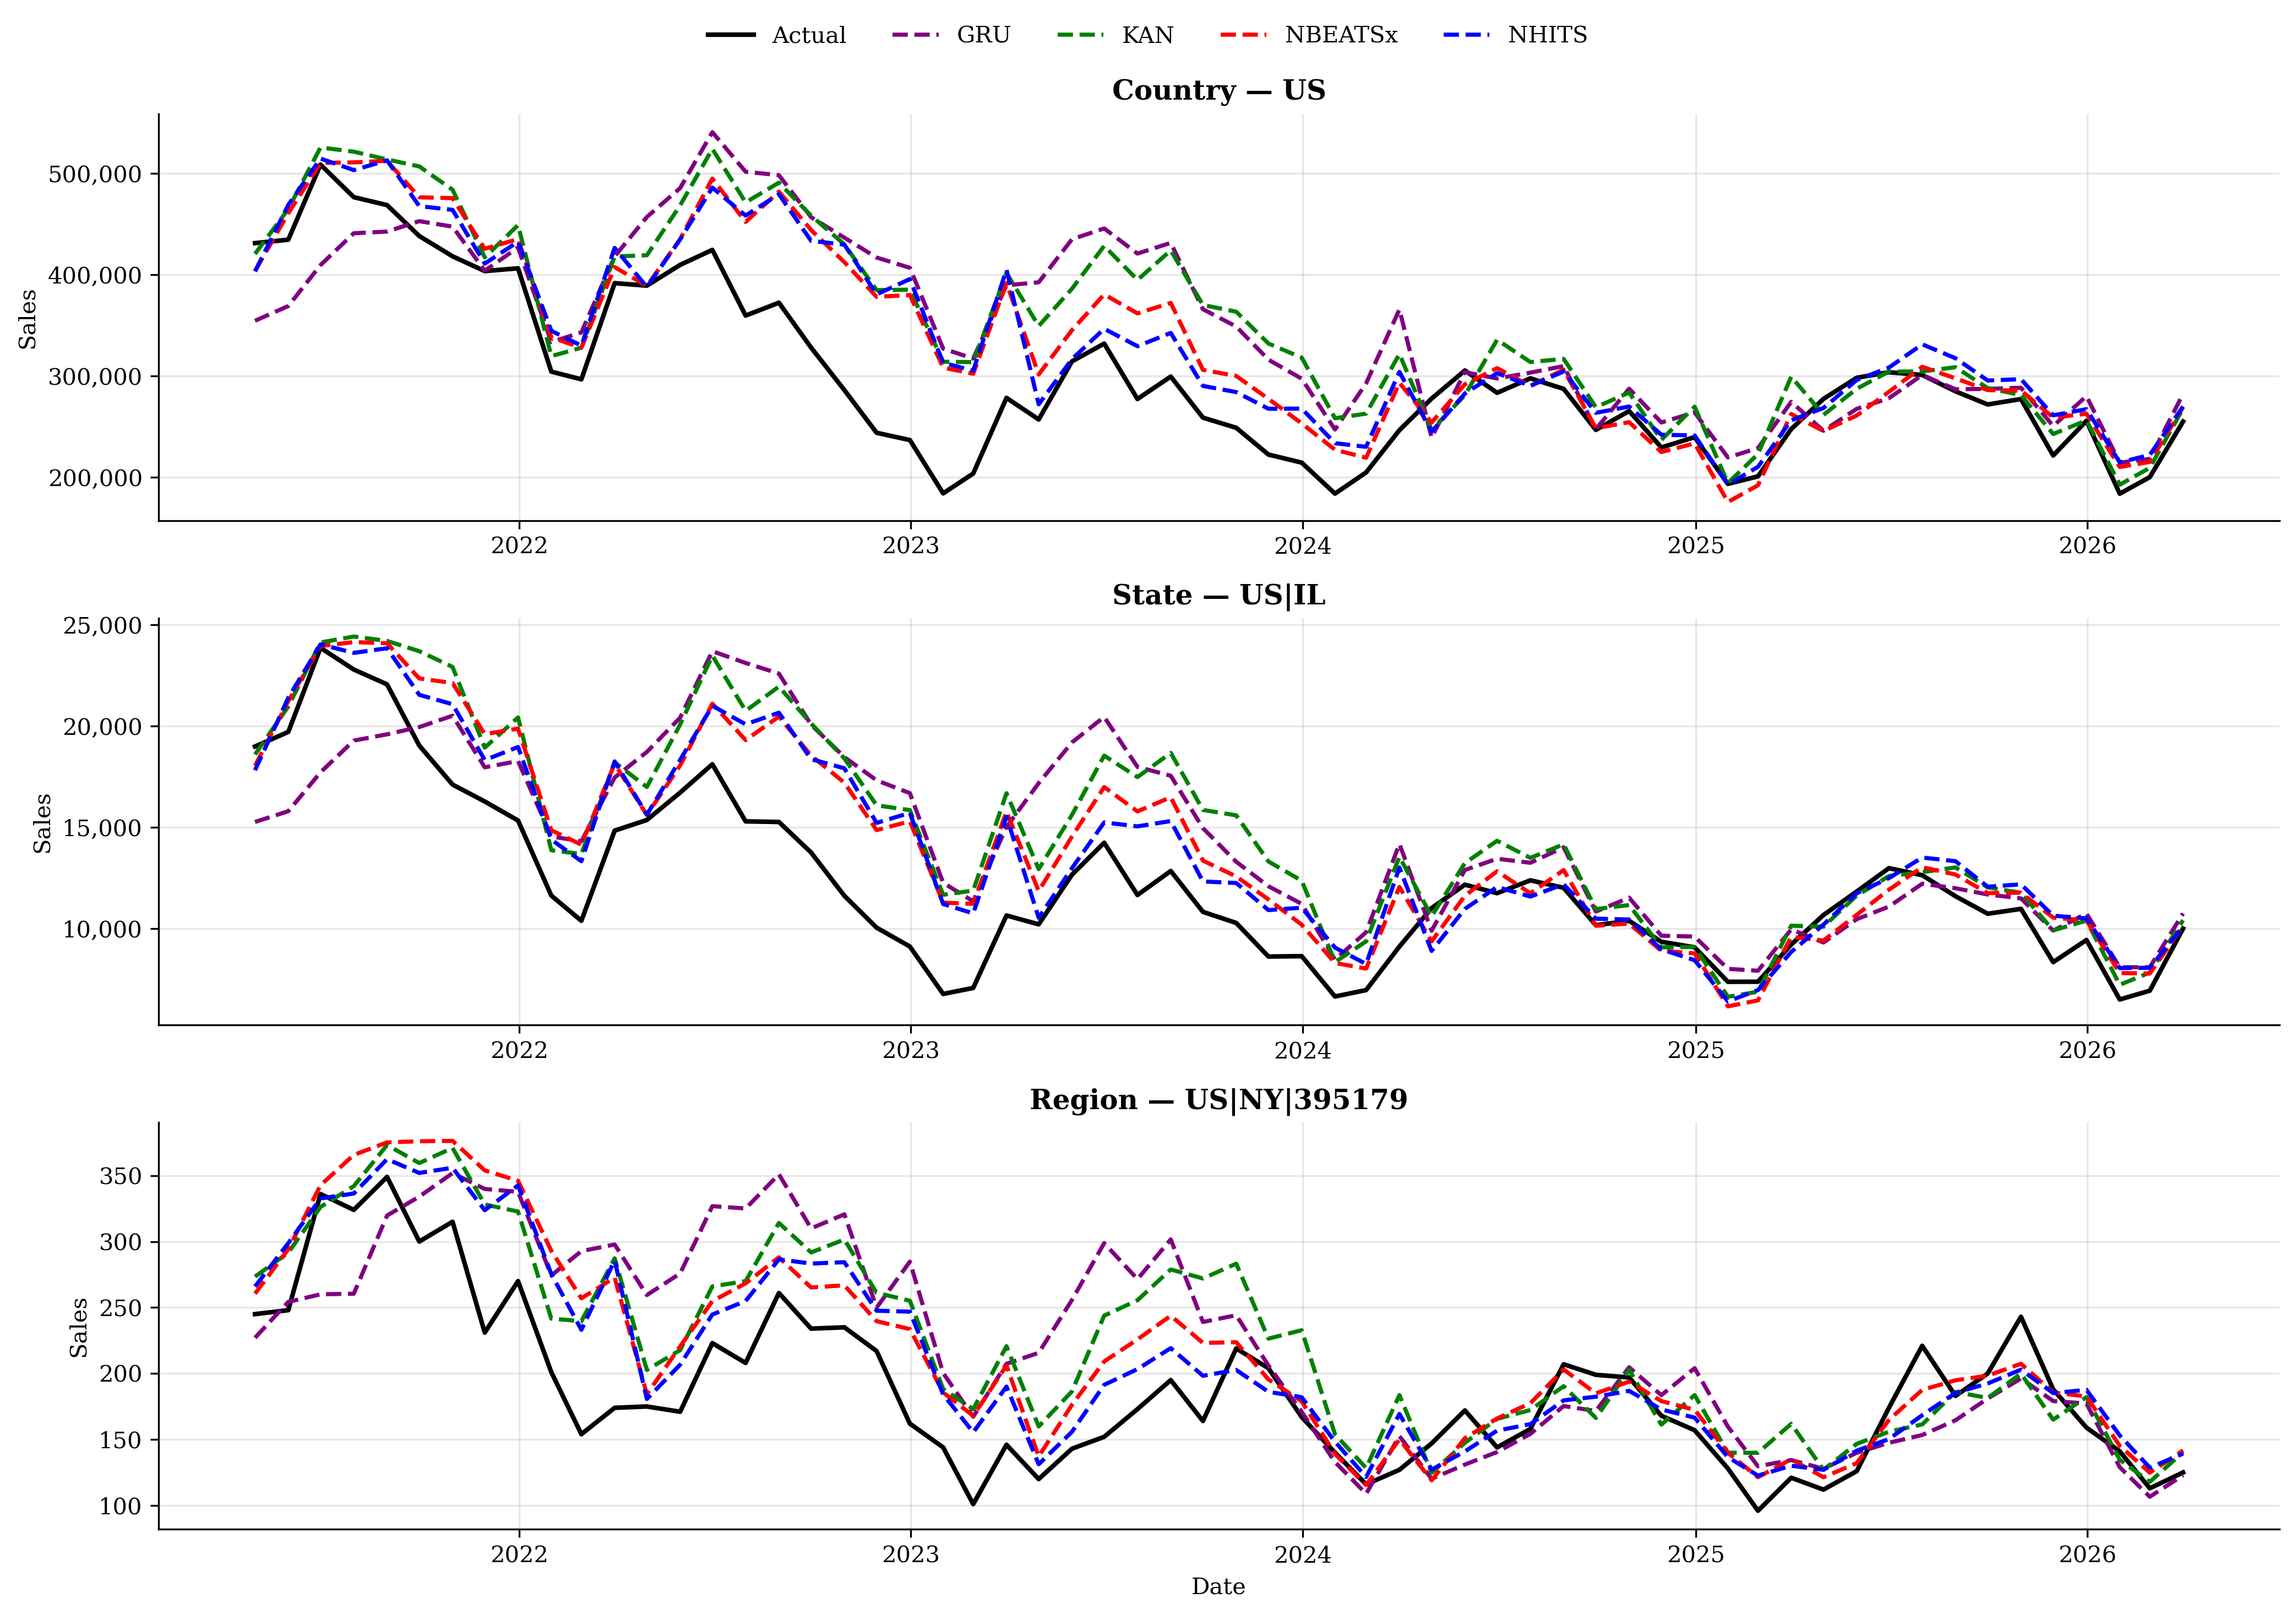

In [14]:
out_df = pred_all.query("type == 'out_sample'").copy()
out_df["ds"] = pd.to_datetime(out_df["ds"])

sample_ids = (out_df[["unique_id", "hierarchy_level", "RegionName"]]
    .drop_duplicates()
    .groupby("hierarchy_level", group_keys=False)
    .sample(1, random_state=42)
    .sort_values("hierarchy_level"))

level_names = {0: "Country", 1: "State", 2: "Region"}

model_colors = {"NHITS": "blue", "NBEATSx": "red", "KAN": "green", "GRU": "purple"}

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)
for ax, row in zip(axes, sample_ids.itertuples(index=False)):
    s = out_df[out_df["unique_id"] == row.unique_id].copy()

    actual = s.groupby("ds", as_index=False)["y"].first().sort_values("ds")
    forecast = (
        s.groupby(["ds", "model"], as_index=False)["forecast"]
        .mean()
        .sort_values(["model", "ds"]))

    ax.plot(actual["ds"], actual["y"], color="black", linewidth=2, label="Actual")

    for model, g in forecast.groupby("model", sort=False):
        ax.plot(
            g["ds"],
            g["forecast"],
            color=model_colors.get(model, "gray"),
            linestyle="--",
            linewidth=1.8,
            label=model
        )

    ax.set_title(f"{level_names[row.hierarchy_level]} — {row.unique_id}", fontweight="bold")
    ax.set_ylabel("Sales")
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
    ax.grid(True, alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[-1].set_xlabel("Date")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=5, frameon=False, bbox_to_anchor=(0.5, 0.98))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()